In [1]:
from pyDOE import *
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset
import pandas as pd
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math 
from torch.autograd import grad
from data_generator import Schrodinger_Boundary, Schrodinger_Initial, Schrodinger

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Torch utilizing dev",device)

Torch utilizing dev cpu


# Training data

In [2]:
num_col_bound = 50
num_h_init = 50
num_col_schro = 20000

boundary = Schrodinger_Boundary(num_col_bound)
initial = Schrodinger_Initial(num_h_init)
schrodinger = Schrodinger(num_col_schro)

schrodinger_dl = DataLoader(schrodinger, batch_size=4096, shuffle=True)

c:\Users\Lorenz\Masterthesis\Git\ZnPINNLab\day2\data_generator.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(h_func(self.x)).float().to(device),


In [3]:
def create_training_data(
        boundary_vals, 
        initial_vals, 
        schrodinger_vals,
        num_col_train = 20000
    ):
    """
    Create training and test data for training procedure.

    This function generates training and test datasets using a subset
    of the boundary values , initial values and the schrodinger values.
    Therefore the following steps need to be done:
    

    Step 1: Data Point Selection
            Select evenly spaced values from the 'schrodinger_vals' tensor:

            - Create a tensor 'all_idx' containing indices between 0 
              and len(schrodinger_vals)-1 to select data points.
            - Create a tensor 'idx_train' containing 'num_t_train'evenly spaced indices 
              between 0 and the length of the 'schrodinger_vals' tensor to select data points.
            - Generate a mask with booleans of len(all_idx) that gives False statements for entries
              that are both in 'all_idx' and in 'idx_train'.
            - Build a tensor 'idx_test' by applying the mask on 'all_idx'.
            - Ensure that the data type of all idx tensors are integer.

    Step 2: Training Data Creation
            - Define 'schrodinger_train'tensor by selecting index values 'idx_train' 
              from 'schrodinger_vals' and 'position_vals'.
            - We don't want to make changes to the original data therefore use '.clone().detach()'.
        
    Step 3: Testing Data Creation
            Repeat the procedure of step to by selecting index values 'idx_test'.

    Step 4: Dataset Creation
            - Create datasets train_ds and test_ds by using dictionaries 
              containing "boundary", "initial", "schrodinger" and "t_col"(if already defined) entries.
            - Use the getall method in order to extract tensors for the "boundary" and "initial" keys.
              
        
    Step 5:  Return the created datasets.
    
    Parameters
    ----------
    boundary_vals : torch.Tensor
        A tensor containing boundary values.
    initial_vals : torch.Tensor
        A tensor containing initial values.
    schrodinger_vals : torch.Tensor
        A tensor containing Schrödinger values.
    num_t_col : int, optional
        The number of evenly spaced time values to generate in 't_col'. Default is 100.
        
    Returns
    -------
    Dict
        A dictionary containing "boundary," "initial," and "schrodinger" entries for training data.
    Dict
        A dictionary containing "boundary," "initial," and "schrodinger" entries for testing data.
    """
    
    # Step 1: Create a tensors of indices that correspond to the selected time values.
    all_idx = torch.arange(0, len(schrodinger_vals)-1, dtype=torch.int)
    idx_train = torch.linspace(0, len(schrodinger_vals)-1, num_col_train, dtype=torch.int)
    mask = ~torch.isin(all_idx, idx_train)
    idx_test = all_idx[mask]
    
    # Step 2: - Get t_train, x_train and y_train by selecting values from the provided data.
    schrodinger_train = schrodinger_vals[idx_train].clone().detach()

    # Step 3: Get t_test, x_test, y_test from the provided data
    schrodinger_test = schrodinger_vals[idx_test].clone().detach()

    
    # Step 5: Create datasets train_ds and test_ds by using dictionaries 
    train_ds = {"boundary": boundary_vals.getall(), "initial": initial_vals.getall(),"schrodinger": schrodinger_train}
    test_ds = {"boundary": boundary_vals.getall(), "initial": initial_vals.getall(),"schrodinger": schrodinger_test}

    # Step 6: return datasets
    return train_ds, test_ds


In [4]:
train_ds, test_ds = create_training_data(boundary, initial, schrodinger)


# Train PINN on Non-Linear Schrodinger's Equation

$ih_{t} + 0.5h_{xx} + h|h|^{2}= 0$ 

Boundary conditions

*   $h(t,5)=h(t,-5)$ 

*   $h_{x}(t,5)=h_{x}(-t,5)$

Regularization


* $f(x,t) = ih_{t} + 0.5h_{xx} + h|h|^{2}= 0$ 
 

Neural network approximates $h(x,t)$ with real-numbered u,v outputs representing the real and complex parts respectively. MSE for complex & real parts are calculated separately without use of PyTorch complex numbers



Trained over 20,000 epochs at lr=0.0025 using CUDA

In [5]:
class PINN(nn.Module):
    """
    Physics-Informed Neural Network (PINN) Class
    
    This class as a subclass of torch.nn.Module defines the architecture of the PINN model. 
    It is designed to use differential equations while incorporating physics-based constraints.
    The process consists of the following steps:
    
    Step 1: Model Initialization
        - Initialize the PINN model as a subclass of nn.Module.

    Step 2: Constructor Definition
        - Build a constructor to configure the model's architecture.
        - Utilize the nn.Linear class from the PyTorch library for defining layers and connections.

    Step 3: Forward Pass Mechanism
        - Define the forward pass mechanism for the model, where input data flows through the layers
          to produce predicted outputs.
       
    """
    def __init__(self):
        """
        Constructor for the PINN class.
        
        Initializes the layers of the neural network:
        - Input layer fc1 taking a tensor with time and space data.
        - Four hidden fully connected layers fc2-fc5 with 100 neurons.
        - Output layer h_real for predicting the real part.
        - Output layer h_imag for predicting the imaginary part.
        
        Parameters
        ----------
        None
            
        Attributes
        ----------
        fc1 : nn.Linear
            First fully connected layer.
        fc2 : nn.Linear
            Second fully connected layer.
        fc3 : nn.Linear
            Third fully connected layer.
        fc4 : nn.Linear
            Fourth fully connected layer.
        fc5 : nn.Linear
            Fifth fully connected layer.
        h_real : nn.Linear
            Output layer for x-coordinate prediction.
        h_imag : nn.Linear
            Output layer for y-coordinate prediction.
        
        Returns
        -------
        None
        
        """
        super(PINN, self).__init__()
        
        # Step 2: Configure model architecture as described earlier
        self.fc1 = nn.Linear(2,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc1.weight)
        self.fc2 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc2.weight)
        self.fc3 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc3.weight)
        self.fc4 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc4.weight)
        self.fc5 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc5.weight)
        self.h_real = nn.Linear(100,1).to(device)
        torch.nn.init.xavier_uniform_(self.h_real.weight)
        self.h_imag = nn.Linear(100,1).to(device)
        torch.nn.init.xavier_uniform_(self.h_imag.weight)
        self.optimizer = optim.Adam(self.parameters(), lr=0.00025)
        pass
    
    def forward(self, X):
        """
        Perform a forward pass through the PINN model.
        
        This method defines the forward pass mechanism of the PINN model, where
        the input data X is processed through the layers to produce predicted
        outputs for both real part of the solution (h_real) 
        and imaginary part of the solution (h_imag).
        The following steps are necessary:
        
    1. Pass input through layers with GELU Activation:
        - Pass the input tensor 'X' through the 'fc1' linear layer.
        - Apply the tanh activation function 'torch.tanh' to the output.
        - reply this procedure for the remaining layers

    2. Output Layer for Predicted Coordinates:
        - Compute the predicted real solution by passing the transformed tensor 'x' 
          through the 'h_real' layer.
        - Compute the predicted imaginary solutiun by passing the same transformed tensor 'x' 
          through the 'h_imag' layer.
        
        Parameters
        ----------
        t : torch.Tensor
            Input data tensor.
            
        Returns
        -------
        Tuple[torch.Tensor, torch.Tensor]
            Predicted real and imaginary solution.
        """

        # Step 1: Apply the tanh activatiom on each fully connected layer.
        x = torch.tanh(self.fc1(X))   
        x = torch.tanh(self.fc2(x))  
        x = torch.tanh(self.fc3(x))  
        x = torch.tanh(self.fc4(x))  
        x = torch.tanh(self.fc5(x))     

        # Step 2: Produce predicted real and imaginary solution using output layers and return them. 
        h_real = self.h_real(x)
        h_imag = self.h_imag(x)

        return h_real, h_imag



Epoch 0 ~ Train Loss 0.9325846433639526
Epoch 5 ~ Train Loss 0.34250491857528687
Epoch 10 ~ Train Loss 0.26718199253082275
Epoch 15 ~ Train Loss 0.21269086003303528
Epoch 20 ~ Train Loss 0.20147131383419037
Final Loss:  tensor(0.1668, grad_fn=<AddBackward0>)


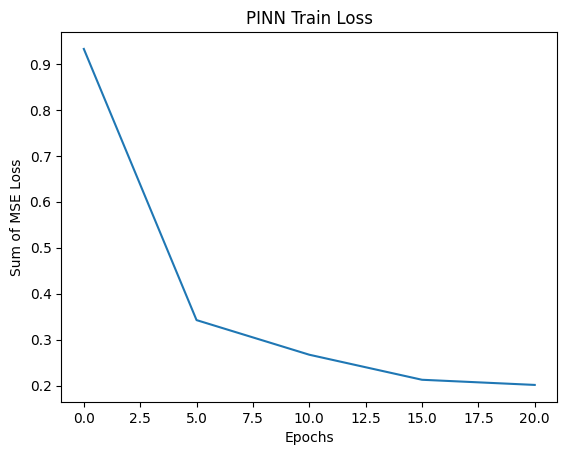

In [6]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        
        # Step 2: Configure model architecture as described earlier
        self.fc1 = nn.Linear(2,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc1.weight)
        self.fc2 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc2.weight)
        self.fc3 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc3.weight)
        self.fc4 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc4.weight)
        self.fc5 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc5.weight)
        self.h_real = nn.Linear(100,1).to(device)
        torch.nn.init.xavier_uniform_(self.h_real.weight)
        self.h_imag = nn.Linear(100,1).to(device)
        torch.nn.init.xavier_uniform_(self.h_imag.weight)
        self.optimizer = optim.Adam(self.parameters(), lr=0.00025)
        pass
    
    def forward(self, X):
        """
        Perform a forward pass through the PINN model.
        
        This method defines the forward pass mechanism of the PINN model, where
        the input data X is processed through the layers to produce predicted
        outputs for both real part of the solution (h_real) 
        and imaginary part of the solution (h_imag).
        The following steps are necessary:
        
    1. Pass input through layers with GELU Activation:
        - Pass the input tensor 'X' through the 'fc1' linear layer.
        - Apply the tanh activation function 'torch.tanh' to the output.
        - reply this procedure for the remaining layers

    2. Output Layer for Predicted Coordinates:
        - Compute the predicted real solution by passing the transformed tensor 'x' 
          through the 'h_real' layer.
        - Compute the predicted imaginary solutiun by passing the same transformed tensor 'x' 
          through the 'h_imag' layer.
        
        Parameters
        ----------
        t : torch.Tensor
            Input data tensor.
            
        Returns
        -------
        Tuple[torch.Tensor, torch.Tensor]
            Predicted real and imaginary solution.
        """

        # Step 1: Apply the tanh activatiom on each fully connected layer.
        x = torch.tanh(self.fc1(X))   
        x = torch.tanh(self.fc2(x))  
        x = torch.tanh(self.fc3(x))  
        x = torch.tanh(self.fc4(x))  
        x = torch.tanh(self.fc5(x))     

        # Step 2: Produce predicted real and imaginary solution using output layers and return them. 
        h_real = self.h_real(x)
        h_imag = self.h_imag(x)

        return h_real, h_imag

    
    def h(self, x, t):
        X = torch.cat((x,t),1).float().to(device)
        return self.forward(X)

    def norm(self, real, compl):
      return torch.sqrt((real**2) + (compl**2))

    def loss(self):
        
        # Initial Condition: h(x,0) = 2sech(x)
        X_0,H_0 = train_ds["initial"]
        X_0.requires_grad = True
        H_0.requires_grad = True
        zeros = torch.zeros((len(X_0),1)).float().to(device)

        h_r, h_c = self.h(X_0,zeros)
        h = torch.cat((h_r, h_c), 1)
         
        J_0 = torch.mean((H_0 - h)**2)

        # Function Condition ih_t + 0.5h_xx + h(|h|**2) = 0
        X = train_ds["schrodinger"]
        X.requires_grad = True
        x = torch.unsqueeze(X[:,0], 1)
        t = torch.unsqueeze(X[:,1], 1)

        hf_r, hf_c = self.h(x,t)

        h_fx_r = grad(outputs=hf_r, inputs=x, grad_outputs=torch.ones_like(hf_r), create_graph=True)[0]
        h_fxx_r = grad(outputs=h_fx_r, inputs=x, grad_outputs=torch.ones_like(h_fx_r), create_graph=True)[0]
        h_ft_r = grad(outputs=hf_r, inputs=t, grad_outputs=torch.ones_like(hf_r), create_graph=True)[0]
        
        h_fx_c = grad(outputs=hf_c, inputs=x, grad_outputs=torch.ones_like(hf_c), create_graph=True)[0]
        h_fxx_c = grad(outputs=h_fx_c, inputs=x, grad_outputs=torch.ones_like(h_fx_c), create_graph=True)[0]
        h_ft_c = grad(outputs=hf_c, inputs=t, grad_outputs=torch.ones_like(hf_c), create_graph=True)[0]

        f_r = (h_ft_r) + (0.5 * h_fxx_c) + (((hf_r**2)+(hf_c**2))*hf_c)   
        f_c = (h_ft_c) - (0.5 * h_fxx_r) - (((hf_r**2)+(hf_c**2))*hf_r) 
        
        J_f = torch.mean(self.norm(f_r,f_c)**2)

        # # Boundary conditions
        tb = train_ds["boundary"]
        tb.requires_grad = True
        fives = torch.ones((len(tb),1), requires_grad=True).to(device)*5.

        hp_r, hp_c = self.h(fives,tb)
        hn_r, hn_c = self.h(-fives,tb)


        hp_r_x = grad(outputs=hp_r, inputs=fives, grad_outputs=torch.ones_like(hp_r), create_graph=True)[0]
        hp_c_x = grad(outputs=hp_c, inputs=fives, grad_outputs=torch.ones_like(hp_c), create_graph=True)[0]

        hn_r_x = grad(outputs=hn_r, inputs=fives, grad_outputs=torch.ones_like(hn_r), create_graph=True)[0]
        hn_c_x = grad(outputs=hn_c, inputs=fives, grad_outputs=torch.ones_like(hn_c), create_graph=True)[0]
        
        h_r_err = torch.unsqueeze(hp_r - hn_r,1)
        h_c_err = torch.unsqueeze(hp_c - hn_c,1)

        h_xr_err = hp_r_x - hn_r_x
        h_xc_err = hp_c_x - hn_c_x

        h_err = (h_r_err**2) + (h_c_err**2)
        h_x_err = (h_xr_err**2) + (h_xc_err**2)

        J_B = torch.mean( (h_err**2) + (h_x_err**2) )

        return J_0 + J_B + J_f 
        
    def train(self,epochs,display_every_n_epochs):
        history = []
        epoch_hist = []
        for i in range(0, epochs):
            self.zero_grad()
            loss = self.loss()
            loss.backward()
            self.optimizer.step()
            if(i % display_every_n_epochs == 0):
                print("Epoch", i, "~ Train Loss" , loss.item())
                history.append(loss.item())
                epoch_hist.append(i)
        print("Final Loss: ", loss)
        return epoch_hist, history
    
_nn = PINN().to(device)
epochs,hist = _nn.train(epochs=25,display_every_n_epochs=5)

plt.plot(epochs,hist)
plt.xlabel("Epochs")
plt.ylabel("Sum of MSE Loss") 
plt.title("PINN Train Loss")
plt.show() 


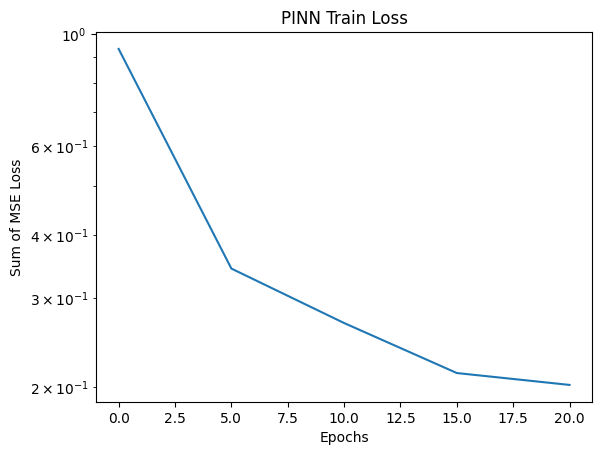

In [7]:
plt.plot(epochs,hist)
plt.xlabel("Epochs")
plt.ylabel("Sum of MSE Loss") 
plt.title("PINN Train Loss")
plt.yscale("log")
plt.show() 

# Plot results & approximated solution



In [20]:
x = np.linspace(-5,5,3)
t = np.linspace(0,math.pi/2,3)

X,T = np.meshgrid(x,t)
_X = torch.tensor(np.dstack((X,T))).float().to(device)
print("t: ", t)
print("X: ", X)
print("T: ", T)
print("_X: ", _X)


t:  [0.         0.78539816 1.57079633]
X:  [[-5.  0.  5.]
 [-5.  0.  5.]
 [-5.  0.  5.]]
T:  [[0.         0.         0.        ]
 [0.78539816 0.78539816 0.78539816]
 [1.57079633 1.57079633 1.57079633]]
_X:  tensor([[[-5.0000,  0.0000],
         [ 0.0000,  0.0000],
         [ 5.0000,  0.0000]],

        [[-5.0000,  0.7854],
         [ 0.0000,  0.7854],
         [ 5.0000,  0.7854]],

        [[-5.0000,  1.5708],
         [ 0.0000,  1.5708],
         [ 5.0000,  1.5708]]])


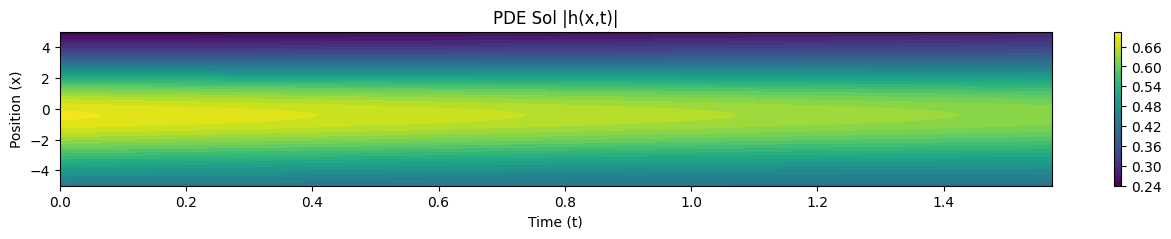

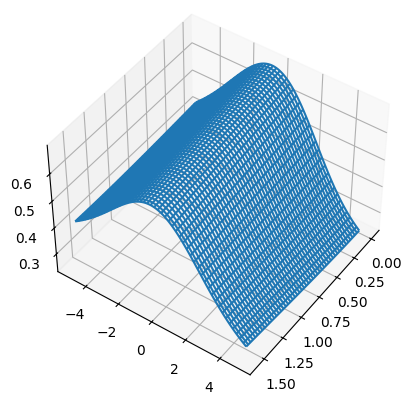

Text(0, 0.5, '|h(t,x)|')

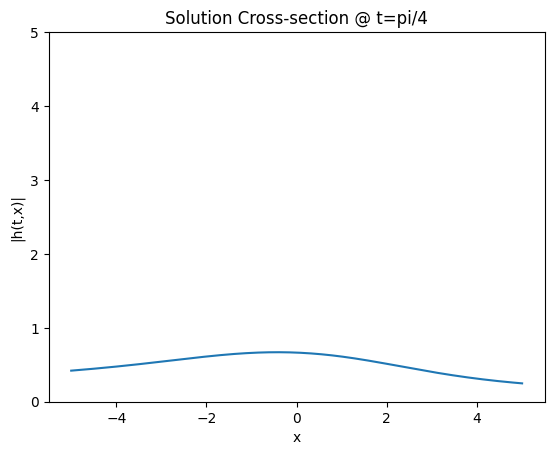

In [28]:
%matplotlib inline

x = np.linspace(-5,5,300)
t = np.linspace(0,math.pi/2,300)

X,T = np.meshgrid(x,t)

_X = torch.tensor(np.dstack((X,T))).float().to(device)

h_r_hat, h_i_hat = _nn.forward(_X)
h_r_hat = h_r_hat.to('cpu').detach()#.numpy()
h_i_hat = h_i_hat.to('cpu').detach()#.numpy()

h_hat = torch.cat((h_r_hat, h_i_hat),2)


h_norm = np.sqrt((h_hat[:,:,0] ** 2) + (h_hat[:,:,1] ** 2))

fig = plt.figure(figsize=(16, 2))
ax = plt.axes()

cf = ax.contourf(T,X,h_norm, 30)
plt.colorbar(cf)

plt.title('PDE Sol |h(x,t)|')
plt.ylabel("Position (x)")
plt.xlabel("Time (t)")
plt.show()

fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot_wireframe(T, X, h_norm, cmap='binary')
ax.view_init(45, 35)
plt.show()

x_slice = x[:]
h_slice = h_norm[100,:]

plt.ylim(0,5)

plt.plot(x_slice,h_slice)
plt.title('Solution Cross-section @ t=pi/4')
plt.xlabel('x')
plt.ylabel('|h(t,x)|')